#### Initialize the libraries, the environment and the client

In [1]:
import pandas as pd
import os

try:
    from epo.tipdata.ops import OPSClient, models, exceptions
except ImportError:
    os.system('pip install epo-tipdata-ops')
    from epo.tipdata.ops import OPSClient, models, exceptions

%load_ext dotenv
%dotenv
%load_ext autoreload
%autoreload 2
    
client = OPSClient(
    key=os.getenv("OPS_KEY"), secret=os.getenv("OPS_SECRET")
)

### 7.3 Image Method
#### 7.3.1 image(path, range, document_format)
* Retrieve the image page for a given path, one page at a time.
* Parameters:<br>  
```image_path (str)```: "published-data/images/EP/1000000/PA/firstpage"<br>
```range```: range=1<br>
```document_format (str)```: document_format='application/tiff'<br>

#### 7.3.2 Example of fetching an image
This example demonstrates how to retrieve an image from a patent application after obtaining the image path using the published_data function returning xml data named image_xml.
* We use published_data to retrieve bibliographic information for the patent application, including image information (constituents=["images"]).

In [2]:
from pprint import pprint
# Identify the image path from image_xml output variable
image_xml = client.published_data(
        reference_type='publication',
        input=models.Docdb("1000000", "EP", "A1", date=None), # 4106326, 1011268, 1708487, 0847197, 0920203, 1435736, 0944269, 1094674
        endpoint='images',
        constituents=[],
        output_type="raw"
    )
pprint(image_xml)

('<?xml version="1.0" encoding="UTF-8"?><?xml-stylesheet type="text/xsl" '
 'href="../../../../style/pub-inquiry.xsl"?>\n'
 '<ops:world-patent-data xmlns="http://www.epo.org/exchange" '
 'xmlns:ops="http://ops.epo.org" xmlns:xlink="http://www.w3.org/1999/xlink">\n'
 '    <ops:document-inquiry>\n'
 '        <ops:publication-reference>\n'
 '            <document-id document-id-type="docdb">\n'
 '                <country>EP</country>\n'
 '                <doc-number>1000000</doc-number>\n'
 '                <kind>A1</kind>\n'
 '            </document-id>\n'
 '        </ops:publication-reference>\n'
 '        <ops:inquiry-result>\n'
 '            <publication-reference>\n'
 '                <document-id document-id-type="docdb">\n'
 '                    <country>EP</country>\n'
 '                    <doc-number>1000000</doc-number>\n'
 '                    <kind>A1</kind>\n'
 '                </document-id>\n'
 '            </publication-reference>\n'
 '            <ops:document-instance s

#### 7.3.3 The variable image_xml will be used for programmatic purposes to:
* Parse the XML response containing the label FirstPageClipping
* Define the namespace correctly from FirstPageClipping to identify the image path
#### Explanation:
1. We extract the image path from the XML data as follows:<br>
    We use xml.etree.ElementTree to parse the XML data. Define the namespace used in the XML for proper querying.<br>
    We use "find" with XPath to locate the document-instance element with the desc attribute set to "FirstPageClipping". Extract the link attribute value, which is the path to the image.<br>
2. We check if the image path exists.<br>
3. If the image path is available, we use the image method to retrieve the image data as a byte stream.<br>
4. Finally, we process or display the image data.<br>

#### Note:
* This example assumes a specific structure for the bibliographic data retrieved by published_data. You might need to adjust it based on the actual format of the data returned by your OPS implementation.<br>
* Make sure you have the necessary libraries to handle the retrieved image data (e.g., libraries for image processing or saving to specific formats).<br>

image path: published-data/images/EP/1000000/PA/firstpage


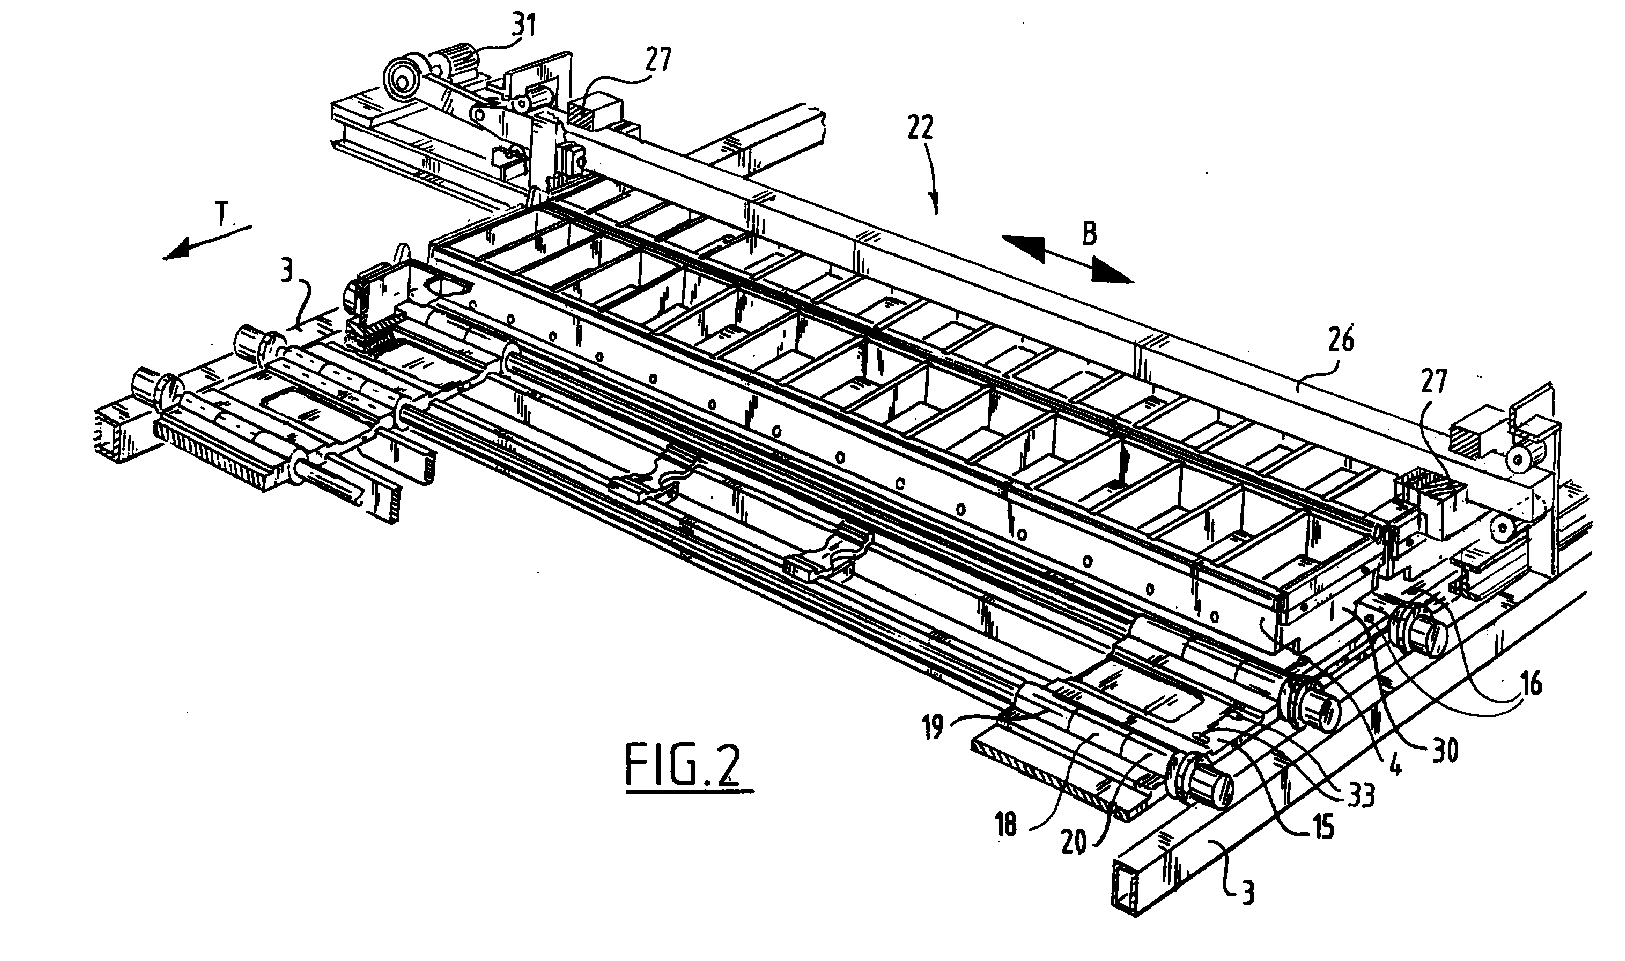

In [3]:
import xml.etree.ElementTree as ET
from IPython.display import display
from PIL import Image
import io
import requests

# Parse the XML to extract the image path
root = ET.fromstring(image_xml)
namespace = {'ops': 'http://ops.epo.org'}

# Extract the path from the 'FirstPageClipping' document instance
first_page_clipping = root.find('.//ops:document-instance[@desc="FirstPageClipping"]', namespace)
if first_page_clipping is not None:
    image_path = first_page_clipping.get('link')
    if image_path:
        print("image path:", image_path)

        fp_image_data = client.image(
            path=image_path,
            range=1,
            document_format='application/tiff',
        )
        fp_image = Image.open(io.BytesIO(fp_image_data))
        display(fp_image)
    else:
        print("FirstPageClipping image path not found.")
else:
    print("FirstPageClipping document instance not found.")

#### 7.3.4 Example of retrieving a pdf file
This code retrieves a PDF file from a specific location using the OPSClient class, saves it temporarily as "temp.pdf", and then creates a downloadable link for the PDF within the IPython notebook ready for display.
*  Retrieve PDF Data:
```fp_pdf_data = client.image(...)```: This line assumes there's a defined client object that can access data. The code snippet calls a method (likely specific to the client library) to retrieve an image. Here it's configured to:<br>
Access a path: ```"published-data/images/EP/1000000/PA/fullimage"``` (This likely points to a specific location within the client system).<br>
Get only one page (```range=1```).<br>
Specify the document format as PDF (```document_format="application/pdf"```).<br>

* Save PDF Data:
```with open("temp.pdf", "wb") as pdf_file```: This line opens a file named "temp.pdf" in write-binary mode (```"wb"```) and assigns it to the variable pdf_file.<br>
```pdf_file.write(fp_pdf_data)```: This line writes the retrieved data (presumably the PDF content) from fp_pdf_data into the opened "temp.pdf" file.<br>

*  display(FileLink("temp.pdf")): 
This line uses the imported ```FileLink``` class to create a link to the "temp.pdf" file that was just created. The ```display``` function then displays this link within the IPython notebook.<br>
Clicking on this link will allow you to download the PDF.<br>

In [4]:
import os
from IPython.display import FileLink

# Here we move temp.pdf to the home directory to avoid saving files on trainings directory.
cwd = os.getcwd()
full_path = "/home/jovyan/temp.pdf"

temp_file = os.path.relpath(full_path, cwd)


fp_pdf_data = client.image(
    path="published-data/images/EP/4106326/PA/fullimage",
    range=1,
    document_format="application/pdf",
)

with open(temp_file, "wb") as pdf_file:
    pdf_file.write(fp_pdf_data)

# Display the PDF using FileLink
display(FileLink(temp_file))

/home/jovyan/temp.pdf